In [210]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

config = {
    "dataset":{
        "dti":"../../Data/scope_onside_common_v3.parquet",
        "adr":"../../Data/final_rxnorm_meddra_v2.parquet"
    },
    "protein_emb_1":{
        "path":  "../../Data/3. Protein_enbeddings/ESM_embeddings_(t33_650m model).parquet",
        "id_col": "id", 
        "emb_col": "embedding"
    },
    "protein_emb_2":{
        "path": "../../Data/3. Protein_enbeddings/GVP-GNN_protein_embeddings.parquet",
        "id_col": "uniprot_id", 
        "emb_col": "embedding"
    },
    "drug_emb_1":{
        "path": "../../Data/2. Drug_embeddings/EGNN_drug_embeddings_v2.parquet", 
        "id_col": "drug_chembl_id", 
        "emb_col": "embedding"
    },
    "drug_emb_2":{
        "path": "../../Data/2. Drug_embeddings/smiles_embeddings_smiles2vec.parquet", 
        "id_col": "drug_chembl_id", 
        "emb_col": "embedding"
    }
}

In [211]:
dti_df = pd.read_parquet(config["dataset"]["dti"])
print(dti_df.info())

# copy selected columns to a new df
# drug_chembl_id as drug_id and target_uniprot_id as protein_id
dti_df = dti_df.rename(columns={"drug_chembl_id": "drug_id", "target_uniprot_id": "protein_id"})

df = dti_df.copy()
df = df[["drug_id", "protein_id", "label", "rxcui"]]


if config["protein_emb_1"]["path"]:
    protein_emb_1_df = pd.read_parquet(config["protein_emb_1"]["path"])
    protein_emb_1_df = protein_emb_1_df.rename(columns={config["protein_emb_1"]["id_col"]: "protein_id"})
    df = df.merge(protein_emb_1_df[["protein_id", config["protein_emb_1"]["emb_col"]]], on="protein_id", how="left")
    df = df.rename(columns={config["protein_emb_1"]["emb_col"]: "prot_emb_1"})

if config["protein_emb_2"]["path"]:
    protein_emb_2_df = pd.read_parquet(config["protein_emb_2"]["path"])
    protein_emb_2_df = protein_emb_2_df.rename(columns={config["protein_emb_2"]["id_col"]: "protein_id"})
    df = df.merge(protein_emb_2_df[["protein_id", config["protein_emb_2"]["emb_col"]]], on="protein_id", how="left")
    df = df.rename(columns={config["protein_emb_2"]["emb_col"]: "prot_emb_2"})

if config["drug_emb_1"]["path"]:
    drug_emb_1_df = pd.read_parquet(config["drug_emb_1"]["path"])
    drug_emb_1_df = drug_emb_1_df.rename(columns={config["drug_emb_1"]["id_col"]: "drug_id"})
    df = df.merge(drug_emb_1_df[["drug_id", config["drug_emb_1"]["emb_col"]]], on="drug_id", how="left")
    df = df.rename(columns={config["drug_emb_1"]["emb_col"]: "drug_emb_1"})

if config["drug_emb_2"]["path"]:
    drug_emb_2_df = pd.read_parquet(config["drug_emb_2"]["path"])
    drug_emb_2_df = drug_emb_2_df.rename(columns={config["drug_emb_2"]["id_col"]: "drug_id"})
    df = df.merge(drug_emb_2_df[["drug_id", config["drug_emb_2"]["emb_col"]]], on="drug_id", how="left")
    df = df.rename(columns={config["drug_emb_2"]["emb_col"]: "drug_emb_2"})



print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34741 entries, 0 to 34740
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   drug_chembl_id     34741 non-null  object
 1   target_uniprot_id  34741 non-null  object
 2   label              34741 non-null  int64 
 3   smiles             34741 non-null  object
 4   sequence           34741 non-null  object
 5   molfile_3d         34741 non-null  object
 6   rxcui              34741 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34741 entries, 0 to 34740
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   drug_id     34741 non-null  object
 1   protein_id  34741 non-null  object
 2   label       34741 non-null  int64 
 3   rxcui       34741 non-null  object
 4   prot_emb_1  34741 non-null  object
 5   prot_emb_2  34741 non

In [212]:
import numpy as np

class ADRData:
    def __init__(self, id_to_name_dict):
        """
        Initializes with a dictionary of {meddra_id: meddra_name}.
        """
        self.id_to_name = id_to_name_dict
        self.unique_ids = sorted(list(id_to_name_dict.keys()))
        
        self.id_to_idx = {adr_id: i for i, adr_id in enumerate(self.unique_ids)}
        self.idx_to_id = {i: adr_id for i, adr_id in enumerate(self.unique_ids)}
        
        self.vocab_size = len(self.unique_ids)

    def encode(self, adr_list):
        """
        Takes a list of ADR IDs and returns a binary vector (1s and 0s).
        Example: ['10028553', '10003041'] -> [0, 1, 0, 0, 1...]
        """
        vector = np.zeros(self.vocab_size, dtype=np.int8)
        
        for adr_id in adr_list:
            if adr_id in self.id_to_idx:
                idx = self.id_to_idx[adr_id]
                vector[idx] = 1
            else:
                print(f"Warning: ADR ID {adr_id} not in vocabulary.")
                
        return vector

    def decode(self, vector):
        """
        Takes a binary vector and returns a list of human-readable ADR names.
        """
        decoded_names = []
        
        active_indices = np.where(vector == 1)[0]
        
        for idx in active_indices:
            adr_id = self.idx_to_id[idx]
            name = self.id_to_name.get(adr_id, "Unknown ADR")
            decoded_names.append(name)
            
        return decoded_names


In [213]:
adrdf = pd.read_parquet(config['dataset']["adr"])
id_name_dict = dict(zip(adrdf['meddra_id'], adrdf['meddra_name']))
adr_manager = ADRData(id_name_dict)

In [214]:
drug_to_adr_list = adrdf.groupby('rxnorm_ingredient_id')['meddra_id'].apply(list).to_dict()

def get_encoded_adr(drug_id):
    # Get the list of ADRs for this drug, or an empty list if not found
    adrs = drug_to_adr_list.get(drug_id, [])
    return adr_manager.encode(adrs)

# 2. Map the drug_id (e.g., rxcui) to the encoded vector
# This will create a column where each cell is a numpy array
df['adr'] = df['rxcui'].map(get_encoded_adr)
print(f"Total rows with ADRs: {df['adr'].apply(lambda x: x.sum() > 0).sum()}")

Total rows with ADRs: 34741


In [215]:
# print number of unique protein and drug ids

print(df["protein_id"].nunique())
print(df["drug_id"].nunique())

# print number of unique rxcui
print(df["rxcui"].nunique())
print(df.head(5))


2385
1028
1028
      drug_id protein_id  label  rxcui  \
0  CHEMBL1000     O15245      0  20610   
1  CHEMBL1000     P08183      1  20610   
2  CHEMBL1000     P35367      1  20610   
3  CHEMBL1000     Q02763      0  20610   
4  CHEMBL1000     Q12809      0  20610   

                                          prot_emb_1  \
0  [-0.041778564453125, 0.0305938720703125, -0.01...   
1  [-0.01091766357421875, -0.0694580078125, -0.07...   
2  [-0.00229644775390625, -0.083740234375, -0.053...   
3  [0.01076507568359375, -0.042083740234375, -0.0...   
4  [0.0037441253662109375, -0.042205810546875, -0...   

                                          prot_emb_2  \
0  [0.143310546875, 0.340087890625, -0.3349609375...   
1  [0.1385498046875, 0.329833984375, -0.325439453...   
2  [0.1802978515625, 0.34619140625, -0.3278808593...   
3  [0.1541748046875, 0.33154296875, -0.326171875,...   
4  [0.1766357421875, 0.342041015625, -0.335693359...   

                                          drug_emb_1  \
0 

In [216]:
from sklearn.model_selection import train_test_split

# 1. Identify the 'Cold' Validation Proteins (The 10 unique ones)
cold_prot_ids = df['protein_id'].drop_duplicates().sample(n=10, random_state=42).values
val_cold_df = df[df['protein_id'].isin(cold_prot_ids)]

# 2. Get the remaining data (everything else)
remaining_df = df[~df['protein_id'].isin(cold_prot_ids)]

# 3. Perform a standard 80/20 split on the remaining data
# We use stratify=y to keep the label distribution consistent
train_df, test_df = train_test_split(
    remaining_df, 
    test_size=0.20, 
    random_state=42, 
    stratify=remaining_df['label']
)

print(f"--- Final Dataset Sizes ---")
print(f"Train Set: {len(train_df)} rows (Standard Training)")
print(f"Test Set:  {len(test_df)} rows (General performance)")
print(f"Val Set:   {len(val_cold_df)} rows (Cold-Protein generalization)")

# 4. Recalculate Positive Weight for Training
num_neg = (train_df['label'] == 0).sum()
num_pos = (train_df['label'] == 1).sum()
pos_weight_value = num_neg / num_pos

print(f"\nNew Positive Weight: {pos_weight_value:.2f}")

--- Final Dataset Sizes ---
Train Set: 27720 rows (Standard Training)
Test Set:  6931 rows (General performance)
Val Set:   90 rows (Cold-Protein generalization)

New Positive Weight: 1.84


In [217]:
import torch
import torch.nn as nn

class FusionModule(nn.Module):
    def __init__(self, dim1, dim2, output_dim):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(dim1 + dim2, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    def forward(self, e1, e2):
        return self.fusion(torch.cat([e1, e2], dim=1))

class MultiTaskFusionVAE(nn.Module):
    def __init__(self, drug_dims, prot_dims, adr_dim=4817, fused_dim=768, latent_dim=256):
        super().__init__()
        
        # 1. Fusion Layers
        # Uses drug_dims (list/tuple e.g., [1024, 512]) and prot_dims
        self.drug_fusion = FusionModule(drug_dims[0], drug_dims[1], fused_dim)
        self.prot_fusion = FusionModule(prot_dims[0], prot_dims[1], fused_dim)
        
        # 2. Contextual Encoder 
        # Variable input: drug fused_dim + protein fused_dim
        encoder_input_dim = fused_dim * 2 
        self.context_encoder = nn.Sequential(
            nn.Linear(encoder_input_dim, 1024), 
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU()
        )
        
        # 3. VAE Bottleneck
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)
        
        # 4. Multi-task Heads
        self.adr_decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, adr_dim)
        )
        
        self.dti_head = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, d1, d2, p1, p2):
        fused_drug = self.drug_fusion(d1, d2) 
        fused_prot = self.prot_fusion(p1, p2)
        
        # Concat the two fused representations
        context_input = torch.cat([fused_drug, fused_prot], dim=1)
        context = self.context_encoder(context_input)
        
        mu = self.fc_mu(context)
        logvar = self.fc_logvar(context)
        z = self.reparameterize(mu, logvar)
        
        adr_logits = self.adr_decoder(z)
        dti_logits = self.dti_head(z)
        
        return dti_logits, adr_logits, mu, logvar

In [218]:
class MultiTaskLossWrapper(nn.Module):
    def __init__(self, num_tasks=2):
        super(MultiTaskLossWrapper, self).__init__()
        # These represent the 'noise' or uncertainty of each task
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))

    def forward(self, loss_dti, loss_adr):
        # Task 1: DTI
        precision1 = torch.exp(-self.log_vars[0])
        loss1 = precision1 * loss_dti + self.log_vars[0]

        # Task 2: ADR
        precision2 = torch.exp(-self.log_vars[1])
        loss2 = precision2 * loss_adr + self.log_vars[1]

        return loss1 + loss2

# Initialize this before the training loop
# loss_balancer = MultiTaskLossWrapper().to(device)
# optimizer.add_param_group({'params': loss_balancer.parameters()})

In [219]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    precision_recall_curve, auc, precision_score, recall_score
)
import numpy as np
import torch

def evaluate_multitask(model, dataloader, device):
    model.eval()
    
    # Storage for DTI targets and predictions
    dti_true, dti_probs = [], []
    # Storage for ADR targets and predictions
    adr_true, adr_probs = [], []

    with torch.no_grad():
        for d1, d2, p1, p2, labels, adr_targets in dataloader:
            d1, d2, p1, p2 = d1.to(device), d2.to(device), p1.to(device), p2.to(device)
            
            # Forward pass
            dti_logits, adr_logits, _, _ = model(d1, d2, p1, p2)
            
            # Convert to probabilities
            dti_p = torch.sigmoid(dti_logits).cpu().numpy()
            adr_p = torch.sigmoid(adr_logits).cpu().numpy()
            
            dti_true.extend(labels.numpy())
            dti_probs.extend(dti_p)
            
            adr_true.extend(adr_targets.numpy())
            adr_probs.extend(adr_p)

    # --- 1. DTI METRICS ---
    dti_true = np.array(dti_true)
    dti_probs = np.array(dti_probs).flatten()
    dti_preds = (dti_probs > 0.5).astype(int)

    # Calculate Precision-Recall AUC (AUPRC)
    precision_pts, recall_pts, _ = precision_recall_curve(dti_true, dti_probs)
    auprc = auc(recall_pts, precision_pts)

    dti_results = {
        "DTI_Accuracy": accuracy_score(dti_true, dti_preds),
        "DTI_F1": f1_score(dti_true, dti_preds),
        "DTI_Precision": precision_score(dti_true, dti_preds),
        "DTI_Recall": recall_score(dti_true, dti_preds),
        "DTI_AUROC": roc_auc_score(dti_true, dti_probs),
        "DTI_AUPRC": auprc
    }

    # --- 2. ADR METRICS (Micro-averaged across 4,817 labels) ---
    adr_true = np.array(adr_true)
    adr_probs = np.array(adr_probs)
    
    # For ADRs, we usually report Micro-average because labels are sparse
    adr_results = {
        "ADR_Micro_AUROC": roc_auc_score(adr_true, adr_probs, average='micro'),
        "ADR_Micro_AUPRC": roc_auc_score(adr_true, adr_probs, average='weighted') # Approx
    }

    return {**dti_results, **adr_results}

In [220]:
from torch.utils.data import Dataset, DataLoader

class DTIVAE_Dataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Drug Inputs (Fusion)
        d1 = torch.tensor(row['drug_emb_1'], dtype=torch.float)
        d2 = torch.tensor(row['drug_emb_2'], dtype=torch.float)
        
        # Protein Inputs (Fusion)
        p1 = torch.tensor(row['prot_emb_1'], dtype=torch.float)
        p2 = torch.tensor(row['prot_emb_2'], dtype=torch.float)
        
        # Targets
        label = torch.tensor(row['label'], dtype=torch.float)
        adr_vector = torch.tensor(row['adr'], dtype=torch.float)
        
        return d1, d2, p1, p2, label, adr_vector



In [ ]:
train_loader = DataLoader(DTIVAE_Dataset(train_df), batch_size=128, shuffle=True)
val_loader = DataLoader(DTIVAE_Dataset(val_cold_df), batch_size=64, shuffle=False)
test_loader = DataLoader(DTIVAE_Dataset(test_df), batch_size=128, shuffle=False)

In [222]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(model, train_loader, test_loader, val_loader, pos_weight, epochs=50, lr=1e-4, device='cuda'):
    model.to(device)
    
    # 1. Initialize the dynamic balancer
    loss_balancer = MultiTaskLossWrapper(num_tasks=2).to(device)
    
    # 2. Setup Optimizer to include balancer parameters
    # This is critical: the balancer needs to be updated by the same optimizer
    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': loss_balancer.parameters(), 'lr': lr}
    ], lr=lr, weight_decay=1e-4)
    
    # Scheduler tracks Val DTI AUPRC to know when to slow down
    scheduler = ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5, verbose=True)
    
    # Weighting for the binary DTI task imbalance
    dti_criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
    
    best_val_auprc = 0
    
    print(f"Starting Training on {device}...")
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        # VAE KL-annealing: Slowly introduce KL loss to keep latent space organized
        beta = min(0.01, epoch * 0.001)
        
        for d1, d2, p1, p2, labels, adr_targets in train_loader:
            d1, d2, p1, p2 = d1.to(device), d2.to(device), p1.to(device), p2.to(device)
            labels, adr_targets = labels.to(device), adr_targets.to(device)
            
            optimizer.zero_grad()
            
            # Forward Pass
            dti_logits, adr_logits, mu, logvar = model(d1, d2, p1, p2)
            
            # Individual Task Losses
            loss_dti = dti_criterion(dti_logits.squeeze(), labels)
            loss_adr = F.binary_cross_entropy_with_logits(adr_logits, adr_targets)
            
            # VAE Loss (KL Divergence)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            kl_loss /= (adr_targets.size(0) * adr_targets.size(1))
            
            # 3. Apply Dynamic Balancing (Replaces static Alpha)
            balanced_task_loss = loss_balancer(loss_dti, loss_adr)
            total_loss = balanced_task_loss + (beta * kl_loss)
            
            total_loss.backward()
            
            # 4. Gradient Clipping: Prevents spikes that cause oscillations
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_losses.append(total_loss.item())
            
        # Evaluation step after each epoch
        test_metrics = evaluate_multitask(model, test_loader, device)
        val_metrics = evaluate_multitask(model, val_loader, device)

        current_auprc = val_metrics['DTI_AUPRC']

        # 5. Checkpointing the Best Model
        if current_auprc > best_val_auprc:
            best_val_auprc = current_auprc
            torch.save(model.state_dict(), 'best_multitask_model.pth')
            print(f"*** New Best Model Saved (AUPRC: {best_val_auprc:.4f}) ***")
            
        # Update learning rate based on performance
        scheduler.step(current_auprc)
        
        # Calculate learned weights for the thesis report
        with torch.no_grad():
            w_dti = torch.exp(-loss_balancer.log_vars[0]).item()
            w_adr = torch.exp(-loss_balancer.log_vars[1]).item()
        
        # Print metrics
        print(f"Epoch {epoch+1}/{epochs} | Loss: {np.mean(train_losses):.4f}")
        print(f"Test DTI AUROC: {test_metrics['DTI_AUROC']:.4f} | Test DTI AUPRC: {test_metrics['DTI_AUPRC']:.4f} | Test ADR AUROC: {test_metrics['ADR_Micro_AUROC']:.4f} | Test ADR AUPRC: {test_metrics['ADR_Micro_AUPRC']:.4f}")
        print(f"Val DTI AUROC: {val_metrics['DTI_AUROC']:.4f} | Val DTI AUPRC: {val_metrics['DTI_AUPRC']:.4f} | Val ADR AUROC: {val_metrics['ADR_Micro_AUROC']:.4f} | Val ADR AUPRC: {val_metrics['ADR_Micro_AUPRC']:.4f}")
        print("-" * 30)

    return model

In [223]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sample_row = train_df.iloc[0]

# Detect Drug Dimensions
d1_dim = len(sample_row['drug_emb_1'])
d2_dim = len(sample_row['drug_emb_2'])

# Detect Protein Dimensions
p1_dim = len(sample_row['prot_emb_1'])
p2_dim = len(sample_row['prot_emb_2'])

# Detect ADR Dimension
num_adrs = adr_manager.vocab_size

print(f"--- Detected Dimensions ---")
print(f"Drug Inputs: {d1_dim}, {d2_dim}")
print(f"Protein Inputs: {p1_dim}, {p2_dim}")
print(f"ADR Output: {num_adrs}")

# --- 2. INITIALIZE MODEL ---
# Dim sizes depend on your specific embeddings (e.g., 768 or 1024)
model = MultiTaskFusionVAE(
    drug_dims=[d1_dim, d2_dim], 
    prot_dims=[p1_dim, p2_dim], 
    adr_dim=num_adrs, 
    fused_dim=1028,
    latent_dim=512  # You can still keep latent_dim as a hyperparameter
).to(device)

# Initialize this before the training loop


Using device: cuda
--- Detected Dimensions ---
Drug Inputs: 256, 256
Protein Inputs: 1280, 1024
ADR Output: 4817


In [224]:
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    pos_weight=1.84,
    epochs=50,
    lr=1e-4,
    device=device
)

Starting Training on cuda...
*** New Best Model Saved (AUPRC: 0.6420) ***
Epoch 1/50 | Loss: 0.6470
Test DTI AUROC: 0.8154 | Test DTI AUPRC: 0.6741 | Test ADR AUROC: 0.9299 | Test ADR AUPRC: 0.6361
Val DTI AUROC: 0.8513 | Val DTI AUPRC: 0.6420 | Val ADR AUROC: 0.9285 | Val ADR AUPRC: 0.6551
------------------------------
*** New Best Model Saved (AUPRC: 0.7437) ***
Epoch 2/50 | Loss: 0.4527
Test DTI AUROC: 0.9012 | Test DTI AUPRC: 0.8212 | Test ADR AUROC: 0.9410 | Test ADR AUPRC: 0.6859
Val DTI AUROC: 0.9059 | Val DTI AUPRC: 0.7437 | Val ADR AUROC: 0.9394 | Val ADR AUPRC: 0.6901
------------------------------
*** New Best Model Saved (AUPRC: 0.7693) ***
Epoch 3/50 | Loss: 0.3496
Test DTI AUROC: 0.8537 | Test DTI AUPRC: 0.7432 | Test ADR AUROC: 0.9418 | Test ADR AUPRC: 0.6918
Val DTI AUROC: 0.8765 | Val DTI AUPRC: 0.7693 | Val ADR AUROC: 0.9387 | Val ADR AUPRC: 0.6866
------------------------------
*** New Best Model Saved (AUPRC: 0.7745) ***
Epoch 4/50 | Loss: 0.2566
Test DTI AUROC: 0.

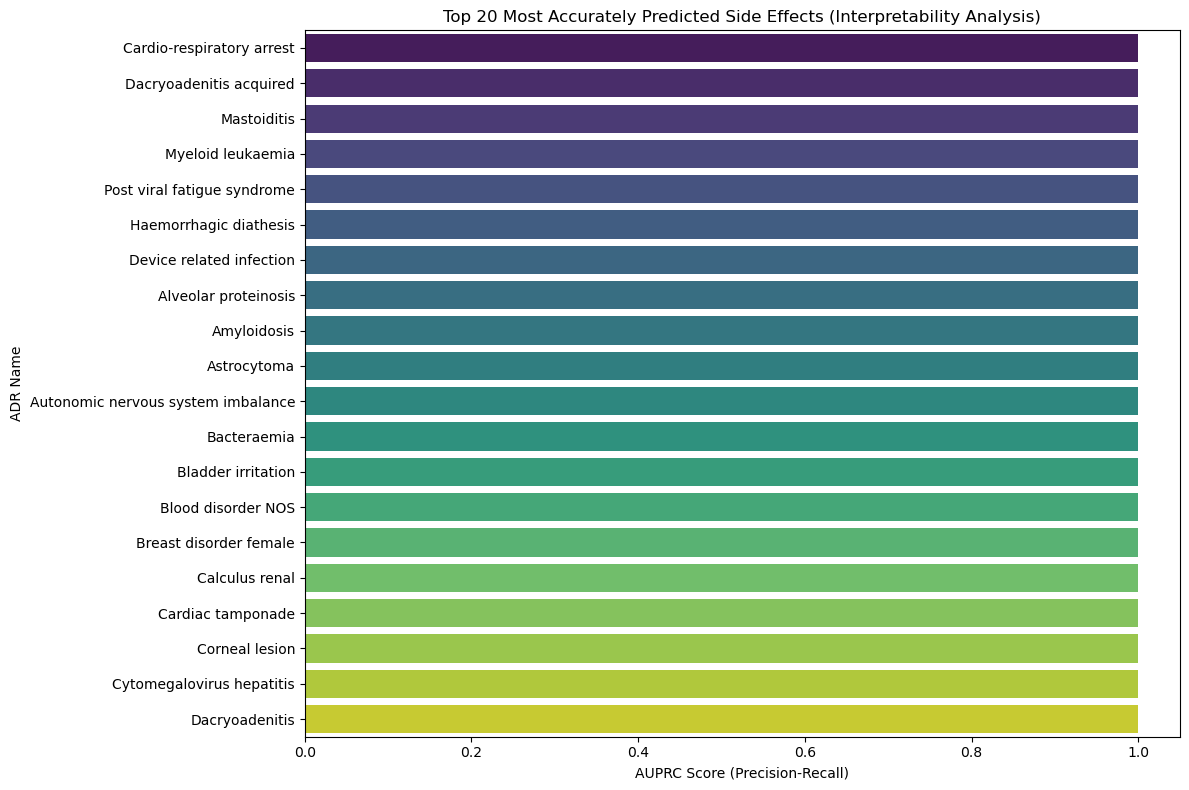

In [225]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

def analyze_adr_performance(model, loader, adr_manager, device, top_n=20):
    model.eval()
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for d1, d2, p1, p2, _, adr_targets in loader:
            _, adr_logits, _, _ = model(d1.to(device), d2.to(device), p1.to(device), p2.to(device))
            all_targets.append(adr_targets.cpu().numpy())
            all_probs.append(torch.sigmoid(adr_logits).cpu().numpy())
            
    all_targets = np.concatenate(all_targets)
    all_probs = np.concatenate(all_probs)
    
    # Calculate AUPRC for each ADR individually
    adr_auprc = []
    for i in range(all_targets.shape[1]):
        if np.sum(all_targets[:, i]) > 0: # Only if ADR exists in set
            score = average_precision_score(all_targets[:, i], all_probs[:, i])
            adr_auprc.append((adr_manager.idx_to_id[i], score))
    
    # Sort and get top N
    adr_auprc.sort(key=lambda x: x[1], reverse=True)
    top_adrs = adr_auprc[:top_n]
    
    # Map IDs to Names for the plot
    plot_data = pd.DataFrame({
        'ADR Name': [adr_manager.id_to_name.get(aid, aid) for aid, score in top_adrs],
        'AUPRC Score': [score for aid, score in top_adrs]
    })
    
    # Create the Heatmap/Barplot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='AUPRC Score', y='ADR Name', data=plot_data, palette='viridis')
    plt.title(f'Top {top_n} Most Accurately Predicted Side Effects (Interpretability Analysis)')
    plt.xlabel('AUPRC Score (Precision-Recall)')
    plt.tight_layout()
    plt.show()

# Run it
analyze_adr_performance(model, test_loader, adr_manager, device)

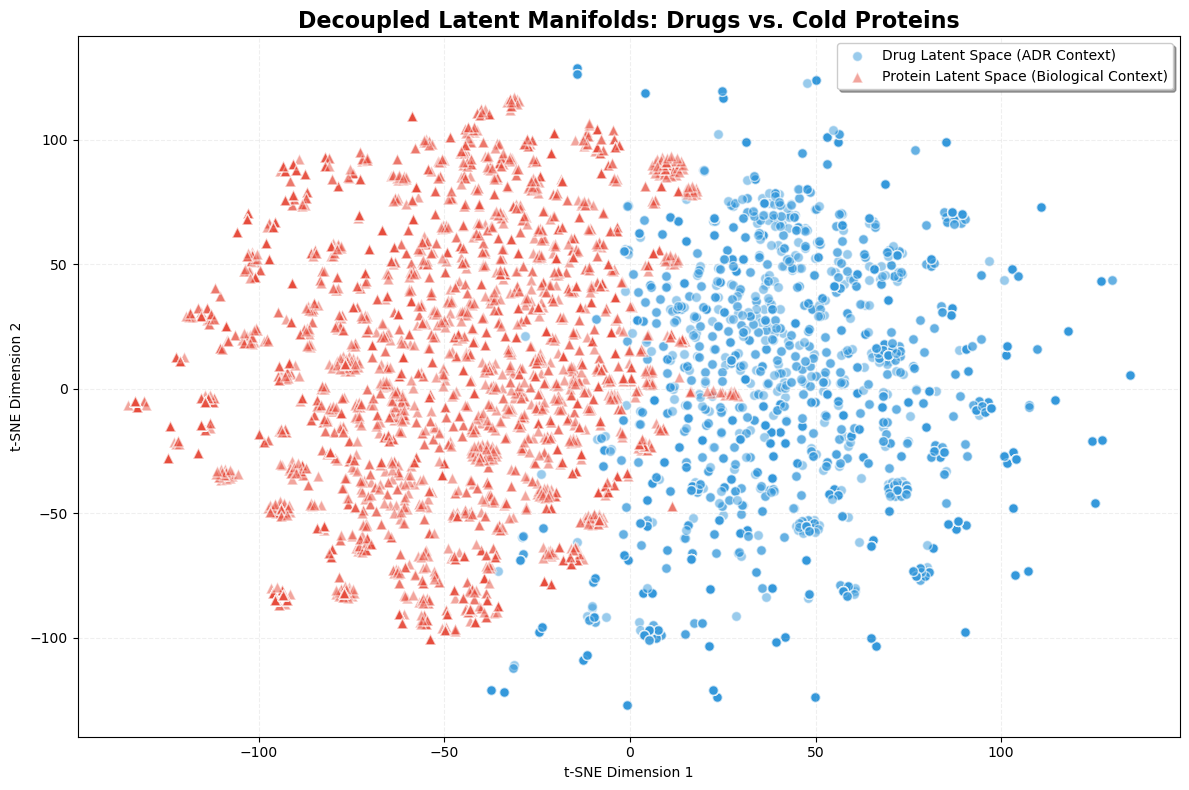

In [226]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_separated_entities(model, loader, device):
    model.eval()
    drug_latents = []
    prot_latents = []
    
    # We use a limited number of batches to keep the t-SNE calculation fast
    with torch.no_grad():
        for i, (d1, d2, p1, p2, _, _) in enumerate(loader):
            # Extract individual fused features
            # These are the outputs of your fusion modules before they are combined
            f_drug = model.drug_fusion(d1.to(device), d2.to(device))
            f_prot = model.prot_fusion(p1.to(device), p2.to(device))
            
            drug_latents.append(f_drug.cpu().numpy())
            prot_latents.append(f_prot.cpu().numpy())
            
            if i > 50: break # Limit to ~50 batches for clear visualization
    
    drugs = np.concatenate(drug_latents)
    prots = np.concatenate(prot_latents)
    all_features = np.vstack([drugs, prots])
    
    # Removed 'n_iter' to prevent the error; 'max_iter' is the modern equivalent
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
    z_2d = tsne.fit_transform(all_features)
    
    z_drugs = z_2d[:len(drugs)]
    z_prots = z_2d[len(drugs):]
    
    plt.figure(figsize=(12, 8))
    
    # Plotting with a slight alpha for better visibility of density
    plt.scatter(z_drugs[:, 0], z_drugs[:, 1], c='#3498db', alpha=0.5, 
                label='Drug Latent Space (ADR Context)', marker='o', edgecolors='w', s=50)
    
    plt.scatter(z_prots[:, 0], z_prots[:, 1], c='#e74c3c', alpha=0.5, 
                label='Protein Latent Space (Biological Context)', marker='^', edgecolors='w', s=60)
    
    plt.title('Decoupled Latent Manifolds: Drugs vs. Cold Proteins', fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.tight_layout()
    plt.show()

# Execute with your trained model
plot_separated_entities(model, test_loader, device)

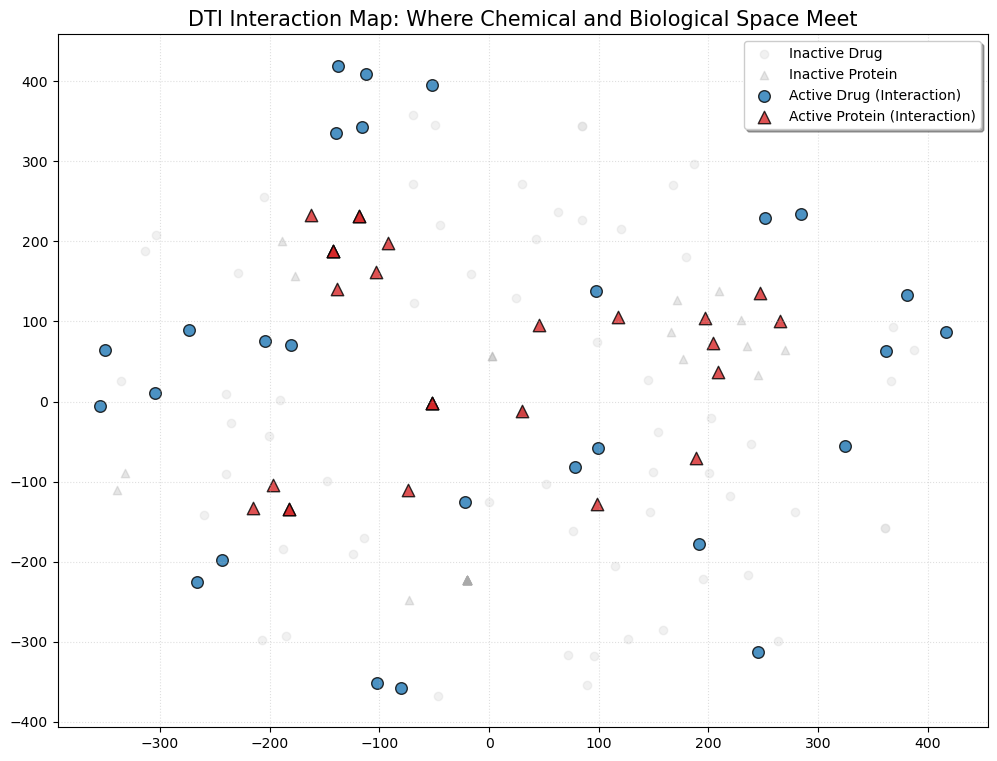

In [227]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_interaction_map(model, loader, device):
    model.eval()
    drug_latents = []
    prot_latents = []
    interaction_labels = []
    
    with torch.no_grad():
        for i, (d1, d2, p1, p2, labels, _) in enumerate(loader):
            f_drug = model.drug_fusion(d1.to(device), d2.to(device))
            f_prot = model.prot_fusion(p1.to(device), p2.to(device))
            
            drug_latents.append(f_drug.cpu().numpy())
            prot_latents.append(f_prot.cpu().numpy())
            interaction_labels.append(labels.cpu().numpy())
            if i > 60: break

    drugs = np.concatenate(drug_latents)
    prots = np.concatenate(prot_latents)
    labels = np.concatenate(interaction_labels)
    
    # Run t-SNE on the combined space
    all_features = np.vstack([drugs, prots])
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    z_2d = tsne.fit_transform(all_features)
    
    z_drugs = z_2d[:len(drugs)]
    z_prots = z_2d[len(drugs):]
    
    plt.figure(figsize=(12, 9))
    
    # 1. Plot Background (Non-interacting)
    plt.scatter(z_drugs[labels==0, 0], z_drugs[labels==0, 1], c='lightgrey', alpha=0.3, label='Inactive Drug')
    plt.scatter(z_prots[labels==0, 0], z_prots[labels==0, 1], c='darkgrey', alpha=0.3, label='Inactive Protein', marker='^')
    
    # 2. Plot Active Pairs (The "Hits")
    # We highlight where the model 'meets' for a successful DTI
    plt.scatter(z_drugs[labels==1, 0], z_drugs[labels==1, 1], c='#1f77b4', alpha=0.8, edgecolors='k', label='Active Drug (Interaction)', s=70)
    plt.scatter(z_prots[labels==1, 0], z_prots[labels==1, 1], c='#d62728', alpha=0.8, edgecolors='k', label='Active Protein (Interaction)', marker='^', s=80)

    plt.title('DTI Interaction Map: Where Chemical and Biological Space Meet', fontsize=15)
    plt.legend(loc='best', shadow=True)
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.show()

plot_interaction_map(model, val_loader, device)

In [160]:
torch.save(model.state_dict(), 'best_multitask_model_latent768_2nd best.pth')